# Solution 3: Optimizing a Multi Link Robotic Arm

# Background Theory and Algorithm

In many engineering applications, we often encounter optimization problems where an explicit analytical solution is difficult or impossible to obtain.

Gradient descent is an iterative algorithm that updates parameters in the direction of steepest descent of a cost (or loss) function. Unlike methods that need higher-order derivatives, this method relies only on first-order derivative information.

This problem requires us to find the joint angles $\theta = [\theta_1, \theta_2, \theta_3]^T$ for a 3-link arm so its end-hook reaches a target $p_t$. We do this by minimizing the squared distance between the current end-hook position and the target, which is our Loss Function $L(\theta)$.

Running Standard Gradient Descent (Task c)...
GD Converged in 682 iterations.
Final Angles (GD): 30.09, 102.33, 49.57 degrees

Running GD with Momentum (Task d)...
Momentum Converged in 89 iterations.
Final Angles (Momentum): 24.98, 109.95, 40.84 degrees

Plotting paths...
Plot saved as 'robot_arm_paths.png'


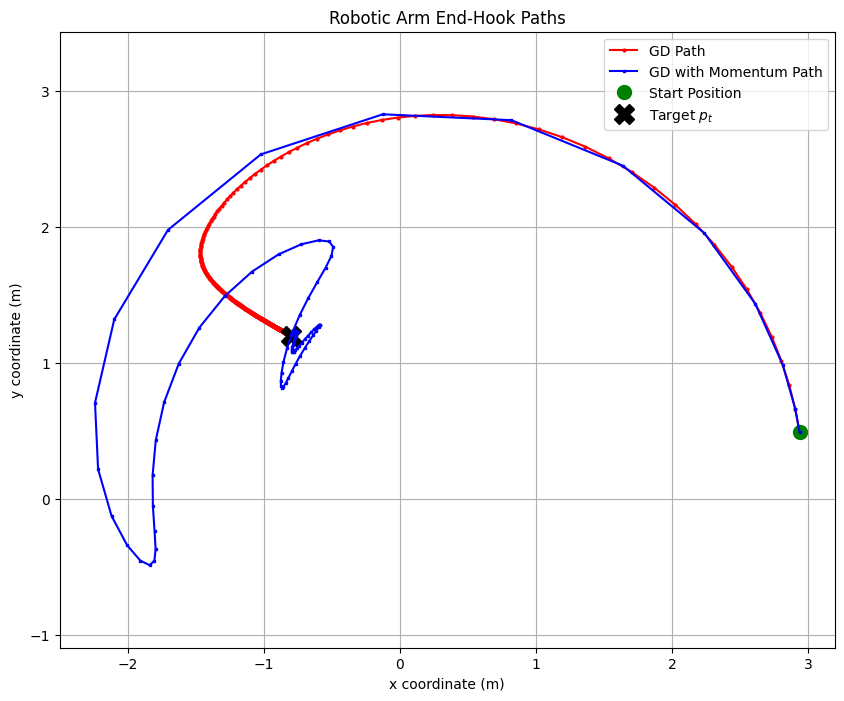

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time


def forward_kinematics(theta, l1=1.0, l2=1.0, l3=1.0):
    th1 = theta[0]
    th2 = theta[1]
    th3 = theta[2]

    x = l1 * np.cos(th1) + l2 * np.cos(th1 + th2) + l3 * np.cos(th1 + th2 + th3)
    y = l1 * np.sin(th1) + l2 * np.sin(th1 + th2) + l3 * np.sin(th1 + th2 + th3)

    return np.array([x, y])

def loss_function(theta, p_target):
    p_current = forward_kinematics(theta)
    return 0.5 * np.sum((p_current - p_target)**2)

def compute_gradient_central_diff(theta, p_target, h):
    grad = np.zeros_like(theta)

    for i in range(len(theta)):
        theta_plus = np.copy(theta)
        theta_plus[i] += h

        theta_minus = np.copy(theta)
        theta_minus[i] -= h

        grad[i] = (loss_function(theta_plus, p_target) - loss_function(theta_minus, p_target)) / (2 * h)

    return grad


p_target = np.array([-0.8, 1.2])
theta_0 = np.array([0.2, 0.1, -0.3])
v_0 = np.array([0.0, 0.0, 0.0])
h = 1e-5
alpha = 0.01
beta = 0.9
conv_threshold = 0.01
max_iter = 20000

print("Running Standard Gradient Descent (Task c)...")
theta_gd = np.copy(theta_0)
path_gd = []
iter_gd = 0

for k in range(max_iter):
    p_k = forward_kinematics(theta_gd)
    path_gd.append(p_k)

    distance = np.linalg.norm(p_k - p_target)
    if distance < conv_threshold:
        break

    grad = compute_gradient_central_diff(theta_gd, p_target, h)

    theta_gd = theta_gd - alpha * grad
    iter_gd = k + 1

final_angles_gd = theta_gd * 180 / np.pi

print(f"GD Converged in {iter_gd} iterations.")
print(f"Final Angles (GD): {final_angles_gd[0]:.2f}, {final_angles_gd[1]:.2f}, {final_angles_gd[2]:.2f} degrees")

print("\nRunning GD with Momentum (Task d)...")
theta_mom = np.copy(theta_0)
v = np.copy(v_0)
path_mom = []
iter_mom = 0

for k in range(max_iter):
    p_k = forward_kinematics(theta_mom)
    path_mom.append(p_k)

    distance = np.linalg.norm(p_k - p_target)
    if distance < conv_threshold:
        break

    grad = compute_gradient_central_diff(theta_mom, p_target, h)

    v = beta * v + alpha * grad
    theta_mom = theta_mom - v
    iter_mom = k + 1

final_angles_mom = theta_mom * 180 / np.pi

print(f"Momentum Converged in {iter_mom} iterations.")
print(f"Final Angles (Momentum): {final_angles_mom[0]:.2f}, {final_angles_mom[1]:.2f}, {final_angles_mom[2]:.2f} degrees")

print("\nPlotting paths...")
path_gd = np.array(path_gd)
path_mom = np.array(path_mom)

plt.figure(figsize=(10, 8))
plt.plot(path_gd[:, 0], path_gd[:, 1], 'r-o', label='GD Path', markersize=2, zorder=2)
plt.plot(path_mom[:, 0], path_mom[:, 1], 'b-s', label='GD with Momentum Path', markersize=2, zorder=3)

plt.plot(path_gd[0, 0], path_gd[0, 1], 'go', markersize=10, label='Start Position')
plt.plot(p_target[0], p_target[1], 'kX', markersize=15, label='Target $p_t$')

plt.title("Robotic Arm End-Hook Paths")
plt.xlabel("x coordinate (m)")
plt.ylabel("y coordinate (m)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.savefig("robot_arm_paths.png", dpi=300, bbox_inches='tight')
print("Plot saved as 'robot_arm_paths.png'")